# Exploração inicial — clima por estação e mês (INMET)

Objetivo: a primeira olhada em `clima_estacao_mes.parquet` — o que é uma linha, quais são as
escalas de cada variável (head e percentis) e onde estão os buracos antes que alguém tente
agregar isso para UF.

Fonte: `data/interim/clima_estacao_mes.parquet`, produzido por
[agrega_mes.py](../src/coleta/inmet/agrega_mes.py) — ticket
[T-014](../tickets/01-coleta/T-014-inmet.md). O caminho é
`ZIP anual do INMET → hora → dia → mês`; os índices de extremo (dias sem chuva, dias de calor
extremo) só podem sair do passo diário, por isso ele existe.

## A pergunta que este notebook responde

> *Já dá para usar direto como feature de UF?*

**Ainda não.** Cada linha é uma **estação automática**, não um estado. RS tem 100 estações e RR
tem 3 — uma média simples por UF daria a Roraima o mesmo peso amostral do Rio Grande do Sul.
Somado a isso, 28% das linhas não têm chuva medida. É esse duplo problema — desequilíbrio
amostral e nulo em massa — que os tickets [T-021](../tickets/02-tratamento/T-021-clima-uf-mes.md)
e [T-022](../tickets/02-tratamento/T-022-clima-ponderado.md) existem para resolver.

Percurso: head e schema (1), a chave e a cobertura temporal (2), os percentis de cada variável
(3), o padrão dos nulos (4), sazonalidade e geografia como sanidade (5), redundância entre
colunas (6).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 3.6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

CAMINHO = Path("..") / "data" / "interim" / "clima_estacao_mes.parquet"

df = pd.read_parquet(CAMINHO)
df["data"] = pd.to_datetime(df["ano_mes"])

print(f"{len(df):,} linhas x {df.shape[1] - 1} colunas")
df.head()

83,814 linhas x 28 colunas


,codigo_estacao,sigla_uf,ano_mes,ano,mes,chuva_mm_mes,temp_media,temp_max_media,temp_min_media,temp_max_abs,temp_min_abs,amplitude_termica_media,umidade_media,umidade_min_abs,radiacao_total_mes,pressao_media_mb,temp_orvalho_media_c,vento_velocidade_media_ms,vento_rajada_max_ms,dias_sem_chuva,dias_chuva_forte,dias_calor_extremo,dias_com_registro,dias_validos_chuva,dias_validos_temp,max_dias_secos_seguidos,dias_no_mes,pct_dias_validos,data
0,A001,DF,2014-01,2014,1,135.80,22.11,27.85,17.34,30.10,15.30,10.52,68.08,24.00,"709,163.90",886.79,15.24,2.39,16.80,22.00,1.00,0.00,31,31,31,15.00,31,100.00,2014-01-01
1,A001,DF,2014-02,2014,2,124.60,21.79,27.24,17.71,30.00,14.80,9.52,70.63,28.00,"566,227.10",885.91,15.58,2.43,15.50,16.00,0.00,1.00,28,28,28,12.00,28,100.00,2014-02-01
2,A001,DF,2014-03,2014,3,305.60,21.19,26.70,17.86,28.40,15.10,8.85,81.52,34.00,"534,822.60",886.50,17.52,2.12,18.50,10.00,1.00,0.00,31,31,31,4.00,31,100.00,2014-03-01
3,A001,DF,2014-04,2014,4,216.00,21.42,27.03,17.50,29.30,14.20,9.53,79.12,30.00,"548,641.10",887.01,17.19,1.99,14.40,16.00,0.00,1.00,30,30,30,5.00,30,100.00,2014-04-01
4,A001,DF,2014-05,2014,5,2.40,20.32,26.40,14.65,28.50,10.80,11.75,65.18,21.00,"555,169.90",887.78,12.98,1.95,9.10,30.00,0.00,2.00,31,31,31,25.00,31,100.00,2014-05-01


---
## 1. Schema: o que é uma linha

Uma linha é **uma estação automática num mês**. As colunas se dividem em três famílias que
convém não misturar: as **médias** (temperatura, umidade, pressão), as **contagens de dias
extremos** (que só existem porque houve um passo diário) e os **medidores de completude**
(`dias_validos_*`, `pct_dias_validos`), que não são clima — são metadado sobre a qualidade da
própria linha.

In [2]:
df.drop(columns="data").info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83814 entries, 0 to 83813
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   codigo_estacao             83814 non-null  object 
 1   sigla_uf                   83814 non-null  object 
 2   ano_mes                    83814 non-null  object 
 3   ano                        83814 non-null  int32  
 4   mes                        83814 non-null  int32  
 5   chuva_mm_mes               60035 non-null  float64
 6   temp_media                 64714 non-null  float64
 7   temp_max_media             64710 non-null  float64
 8   temp_min_media             64712 non-null  float64
 9   temp_max_abs               64710 non-null  float64
 10  temp_min_abs               64712 non-null  float64
 11  amplitude_termica_media    64710 non-null  float64
 12  umidade_media              63575 non-null  float64
 13  umidade_min_abs            63124 non-null  flo

In [3]:
DICIONARIO = {
    "codigo_estacao": ("—", "chave", "código INMET da estação automática (ex.: A001)"),
    "sigla_uf": ("—", "chave", "UF onde a estação fica"),
    "ano_mes": ("mês", "chave", "mês de referência, texto YYYY-MM"),
    "ano": ("ano", "derivada", "componente de ano_mes"),
    "mes": ("1-12", "derivada", "componente de ano_mes; usar para sazonalidade"),
    "chuva_mm_mes": ("mm", "soma", "precipitação acumulada no mês"),
    "temp_media": ("°C", "média", "média das temperaturas horárias"),
    "temp_max_media": ("°C", "média", "média das máximas diárias"),
    "temp_min_media": ("°C", "média", "média das mínimas diárias"),
    "temp_max_abs": ("°C", "extremo", "maior temperatura registrada no mês"),
    "temp_min_abs": ("°C", "extremo", "menor temperatura registrada no mês"),
    "amplitude_termica_media": ("°C", "média", "média diária de (máx − mín)"),
    "umidade_media": ("%", "média", "umidade relativa média"),
    "umidade_min_abs": ("%", "extremo", "menor umidade relativa do mês"),
    "radiacao_total_mes": ("kJ/m²", "soma", "radiação global acumulada"),
    "pressao_media_mb": ("mB", "média", "pressão ao nível da estação (não do mar)"),
    "temp_orvalho_media_c": ("°C", "média", "ponto de orvalho; mede umidade absoluta"),
    "vento_velocidade_media_ms": ("m/s", "média", "velocidade média do vento"),
    "vento_rajada_max_ms": ("m/s", "extremo", "maior rajada do mês"),
    "dias_sem_chuva": ("dias", "contagem", "dias com precipitação nula"),
    "dias_chuva_forte": ("dias", "contagem", "dias acima do limiar de chuva forte"),
    "dias_calor_extremo": ("dias", "contagem", "dias acima do limiar de calor"),
    "max_dias_secos_seguidos": ("dias", "contagem", "maior sequência seca dentro do mês"),
    "dias_com_registro": ("dias", "qualidade", "dias com alguma leitura da estação"),
    "dias_validos_chuva": ("dias", "qualidade", "dias com leitura de chuva aproveitável"),
    "dias_validos_temp": ("dias", "qualidade", "dias com leitura de temperatura aproveitável"),
    "dias_no_mes": ("dias", "qualidade", "28 a 31; denominador dos anteriores"),
    "pct_dias_validos": ("%", "qualidade", "cobertura da linha; o filtro natural do T-021"),
}

pd.DataFrame(
    [(c, u, f, d) for c, (u, f, d) in DICIONARIO.items()],
    columns=["coluna", "unidade", "tipo", "o que é"],
).set_index("coluna")

,unidade,tipo,o que é
coluna,,,
codigo_estacao,—,chave,código INMET da estação automática (ex.: A001)
sigla_uf,—,chave,UF onde a estação fica
ano_mes,mês,chave,"mês de referência, texto YYYY-MM"
ano,ano,derivada,componente de ano_mes
mes,1-12,derivada,componente de ano_mes; usar para sazonalidade
chuva_mm_mes,mm,soma,precipitação acumulada no mês
temp_media,°C,média,média das temperaturas horárias
temp_max_media,°C,média,média das máximas diárias
temp_min_media,°C,média,média das mínimas diárias


In [4]:
print("estações :", df["codigo_estacao"].nunique())
print("UFs      :", df["sigla_uf"].nunique())
print("meses    :", df["ano_mes"].nunique(), f'({df["ano_mes"].min()} → {df["ano_mes"].max()})')
print("duplicatas (estação, mês):", int(df.duplicated(["codigo_estacao", "ano_mes"]).sum()))

estações : 701
UFs      : 27
meses    : 151 (2014-01 → 2026-07)
duplicatas (estação, mês): 0


A chave `codigo_estacao × ano_mes` é única — nenhuma estação aparece duas vezes no mesmo mês.
Repare que `ano_mes` é **texto** `YYYY-MM`, não `datetime`. Ordena certo em ordem alfabética
(por isso funciona), mas qualquer aritmética de data precisa converter antes — foi o que a
coluna `data` fez na primeira célula.

---
## 2. Cobertura: o grid é esburacado, e por um bom motivo

Diferente de uma tabela de painel fechada, aqui **não existe linha para toda combinação
estação × mês**. Estações entram em operação ao longo do tempo.

In [5]:
esperado = df["codigo_estacao"].nunique() * df["ano_mes"].nunique()

print(f"grid cheio (701 estações x 151 meses): {esperado:,}")
print(f"linhas observadas                    : {len(df):,}")
print(f"preenchimento do grid                : {len(df) / esperado * 100:.1f}%")

grid cheio (701 estações x 151 meses): 105,851
linhas observadas                    : 83,814
preenchimento do grid                : 79.2%


In [6]:
por_ano = df.groupby("ano").agg(linhas=("codigo_estacao", "size"), estacoes=("codigo_estacao", "nunique"))
por_ano["meses_no_ano"] = df.groupby("ano")["mes"].nunique()
por_ano

,linhas,estacoes,meses_no_ano
ano,,,
2014,5681,475,12
2015,5746,484,12
2016,5983,529,12
2017,6559,563,12
2018,7041,596,12
2019,7017,589,12
2020,7068,589,12
2021,7056,588,12
2022,6780,567,12


A rede **cresce**: 475 estações ativas em 2014, 638 em 2026. O buraco de 21% no grid é a rede
sendo construída, não falha de coleta — uma estação instalada em 2019 não tem como ter linha em
2014.

**2026 tem só 7 meses** (janeiro a julho). É a fronteira do dado disponível; qualquer média
anual de 2026 estará comparando meia primeira metade do ano contra anos completos, e a
sazonalidade da chuva (seção 5) faz disso um erro grande.

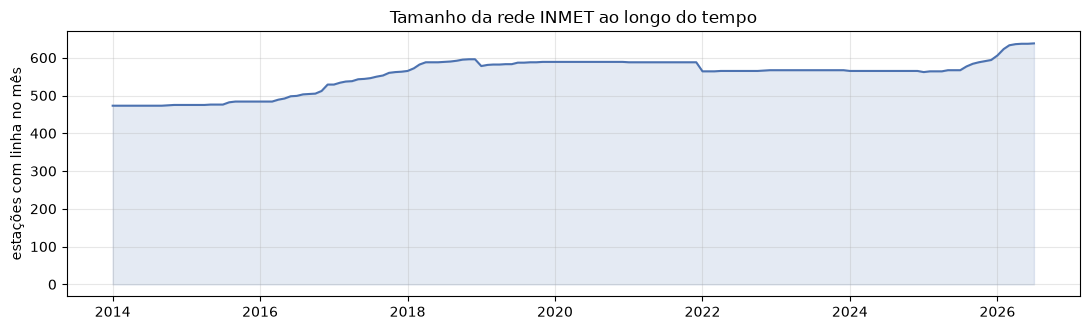

In [7]:
fig, ax = plt.subplots(figsize=(11, 3.4))
ativas = df.groupby("data")["codigo_estacao"].nunique()
ax.plot(ativas.index, ativas.values, color="#4C72B0")
ax.fill_between(ativas.index, ativas.values, alpha=0.15, color="#4C72B0")
ax.set_ylabel("estações com linha no mês")
ax.set_title("Tamanho da rede INMET ao longo do tempo")
fig.tight_layout()
plt.show()

---
## 3. Percentis: a escala de cada variável

O `describe` com percentis largos (1%, 5%, 95%, 99%) é mais informativo que média e desvio
sozinhos, porque quase toda variável aqui é assimétrica — chuva em especial.

In [8]:
MEDIDAS = [
    "chuva_mm_mes",
    "temp_media",
    "temp_max_media",
    "temp_min_media",
    "temp_max_abs",
    "temp_min_abs",
    "amplitude_termica_media",
    "umidade_media",
    "umidade_min_abs",
    "radiacao_total_mes",
    "pressao_media_mb",
    "temp_orvalho_media_c",
    "vento_velocidade_media_ms",
    "vento_rajada_max_ms",
    "dias_sem_chuva",
    "dias_chuva_forte",
    "dias_calor_extremo",
    "max_dias_secos_seguidos",
]

df[MEDIDAS].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
chuva_mm_mes,"60,035.00",113.50,112.36,0.00,0.00,0.00,22.10,82.20,172.80,335.40,469.33,"1,380.80"
temp_media,"64,714.00",23.39,3.88,5.61,12.13,15.62,21.25,24.26,26.21,28.29,29.78,35.47
temp_max_media,"64,710.00",29.77,4.21,9.96,17.40,21.33,27.56,30.52,32.58,35.61,37.41,43.44
temp_min_media,"64,712.00",18.78,4.04,-1.70,7.64,10.97,16.36,19.58,21.93,23.90,25.03,30.02
temp_max_abs,"64,710.00",33.74,3.53,15.00,23.70,27.40,31.80,34.00,36.10,39.10,40.80,45.00
temp_min_abs,"64,712.00",14.94,5.91,-9.90,-1.00,3.10,11.40,16.25,19.70,22.10,23.20,26.20
amplitude_termica_media,"64,710.00",10.99,2.68,2.51,5.36,7.00,9.20,10.71,12.54,15.92,18.37,22.70
umidade_media,"63,575.00",72.00,11.98,7.00,37.56,47.67,65.84,74.69,80.54,86.92,90.67,100.00
umidade_min_abs,"63,124.00",29.25,11.59,4.00,10.00,12.00,21.00,28.00,37.00,50.00,58.00,91.00
radiacao_total_mes,"72,808.00","510,651.82","167,706.69",0.00,"4,910.54","172,890.62","434,155.00","534,352.75","614,374.10","728,421.69","818,394.41","2,584,487.60"


Lendo linha a linha, com olho de quem quer detectar valor impossível:

* **`chuva_mm_mes`** — mediana 82 mm, média 113 mm, máximo 1.381 mm. Média bem acima da mediana
  é a assinatura da cauda à direita: chove pouco quase sempre e muito de vez em quando. O p5 é
  **zero** — 5% das estações-mês não registram uma gota. Zero aqui é medição legítima, não nulo.
* **`temp_media`** — de 5,6 °C a 35,5 °C, mediana 24,3 °C. Plausível para o Brasil.
  `temp_min_abs` chega a **−9,9 °C**, o que soa extremo mas é compatível com noites de geada no
  planalto sul.
* **`umidade_media`** — chega ao teto de 100%. É saturação física real, não estouro de escala.
* **`pressao_media_mb`** — 760 a 1.044 mB. O piso de 760 assustaria se fosse pressão ao nível do
  mar, mas esta é **pressão na estação**: quanto mais alta a estação, menor a pressão. Serve
  como proxy grosseiro de altitude, e é por isso que não deve ser interpretada como tempo.
* **`radiacao_total_mes`** — o máximo (2,58 milhões) é ~5× o p99. Vale desconfiar; a unidade é
  acumulada no mês e a escala do INMET muda entre formatos de arquivo ao longo dos anos.
* **`dias_sem_chuva`** — mediana 22 de ~30. O mês típico brasileiro é majoritariamente seco;
  a chuva se concentra em poucos dias.
* **`dias_chuva_forte`** — mediana **zero**, p95 = 2. É uma variável rara, quase um indicador de
  evento. Média não descreve bem esse tipo de coluna.

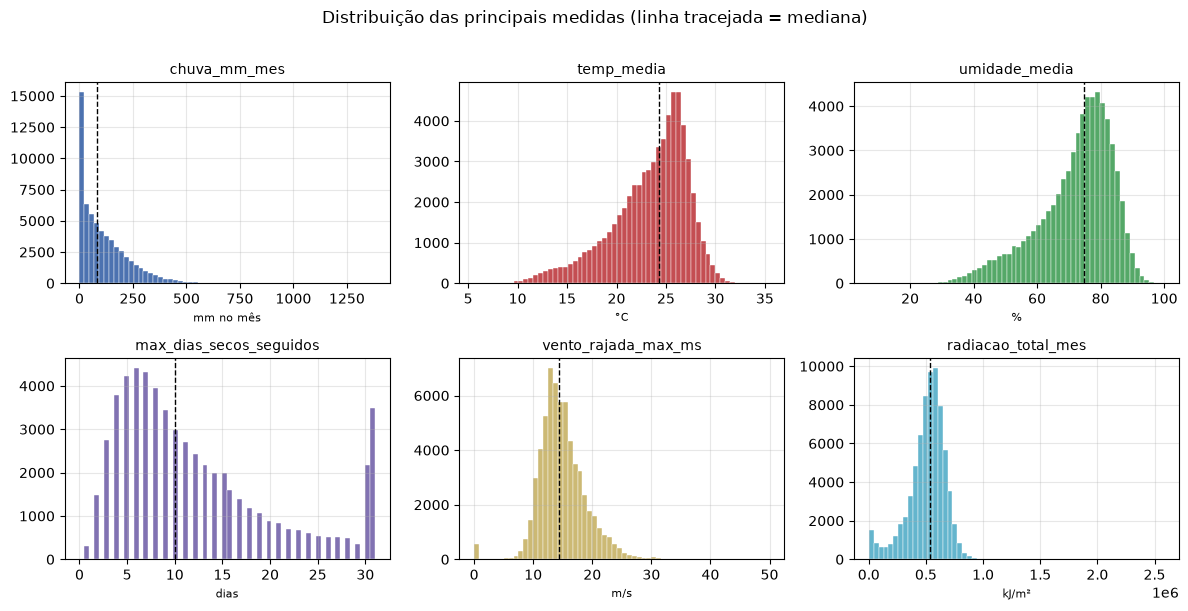

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
alvos = [
    ("chuva_mm_mes", "mm no mês", "#4C72B0"),
    ("temp_media", "°C", "#C44E52"),
    ("umidade_media", "%", "#55A868"),
    ("max_dias_secos_seguidos", "dias", "#8172B2"),
    ("vento_rajada_max_ms", "m/s", "#CCB974"),
    ("radiacao_total_mes", "kJ/m²", "#64B5CD"),
]
for ax, (col, rotulo, cor) in zip(axes.ravel(), alvos):
    ax.hist(df[col].dropna(), bins=60, color=cor, edgecolor="white", linewidth=0.3)
    ax.axvline(df[col].median(), color="black", lw=1, ls="--")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(rotulo, fontsize=8)
fig.suptitle("Distribuição das principais medidas (linha tracejada = mediana)", y=1.01)
fig.tight_layout()
plt.show()

Chuva e sequência seca são fortemente assimétricas; temperatura e umidade são bem mais
comportadas. Isso importa na hora de padronizar: um z-score em `chuva_mm_mes` cru é dominado
pela cauda.

In [10]:
chuva = df["chuva_mm_mes"]
print(f"meses com chuva exatamente zero : {int((chuva == 0).sum()):,}  ({(chuva == 0).mean() * 100:.1f}% dos válidos)")
print(f"meses acima de 300 mm           : {int((chuva > 300).sum()):,}  ({(chuva > 300).mean() * 100:.1f}%)")
print(f"assimetria (skew)               : {chuva.skew():.2f}")

meses com chuva exatamente zero : 4,149  (5.0% dos válidos)
meses acima de 300 mm           : 4,408  (5.3%)
assimetria (skew)               : 1.39


---
## 4. Os nulos: 28% da chuva não existe, e não é aleatório

Este é o ponto que decide o tratamento. Os nulos não estão espalhados de forma uniforme — eles
seguem a **completude da estação naquele mês**.

In [11]:
nulos = df.drop(columns="data").isna().sum().to_frame("nulos")
nulos["pct"] = (nulos["nulos"] / len(df) * 100).round(2)
nulos[nulos["nulos"] > 0].sort_values("pct", ascending=False)

,nulos,pct
chuva_mm_mes,23779,28.37
max_dias_secos_seguidos,23779,28.37
dias_chuva_forte,23779,28.37
dias_sem_chuva,23779,28.37
vento_velocidade_media_ms,21544,25.70
vento_rajada_max_ms,21525,25.68
umidade_min_abs,20690,24.69
temp_orvalho_media_c,20658,24.65
umidade_media,20239,24.15
pressao_media_mb,19267,22.99


Três blocos nítidos, e cada bloco compartilha exatamente o mesmo número de nulos:

| bloco | colunas | nulos |
|---|---|---|
| chuva | `chuva_mm_mes`, `dias_sem_chuva`, `dias_chuva_forte`, `max_dias_secos_seguidos` | 23.779 (28,4%) |
| temperatura | as seis de temperatura + `amplitude_termica_media` + `dias_calor_extremo` | ~19.100 (22,8%) |
| radiação | `radiacao_total_mes` | 11.006 (13,1%) |

Os números idênticos dentro do bloco não são coincidência: as quatro colunas de chuva são
**derivadas do mesmo sensor**. Se o pluviômetro não reportou, as quatro caem juntas. O mesmo
vale para o termômetro. As chaves e os medidores de qualidade, por outro lado, **nunca** são
nulos — o `agrega_mes` sempre sabe quantos dias tinha o mês.

In [12]:
faixas = pd.cut(
    df["pct_dias_validos"],
    [-0.01, 0, 25, 50, 75, 99.99, 100],
    labels=["0%", "0–25%", "25–50%", "50–75%", "75–100%", "100%"],
)
tabela = df.groupby(faixas, observed=True).agg(
    linhas=("chuva_mm_mes", "size"),
    chuva_nula_pct=("chuva_mm_mes", lambda s: s.isna().mean() * 100),
    temp_nula_pct=("temp_media", lambda s: s.isna().mean() * 100),
)
tabela["share_das_linhas"] = (tabela["linhas"] / len(df) * 100).round(1)
tabela.round(1)

,linhas,chuva_nula_pct,temp_nula_pct,share_das_linhas
pct_dias_validos,,,,
0%,13652,98.30,100.00,16.30
0–25%,1825,98.90,100.00,2.20
25–50%,2029,98.50,100.00,2.40
50–75%,2245,72.00,71.00,2.70
75–100%,5131,8.70,0.00,6.10
100%,58932,7.60,0.00,70.30


A leitura desta tabela tem duas partes, e a segunda é a que surpreende.

**A parte esperada:** `pct_dias_validos` explica bem a nulidade de **temperatura**. Acima de 75%
de cobertura, `temp_media` é nula em **0,0%** das linhas; abaixo de 50%, é nula em 100%. A
relação é praticamente determinística.

**A parte que quebra a expectativa:** para **chuva não funciona igual**. Mesmo nas linhas com
100% de cobertura, 7,6% ainda não têm `chuva_mm_mes`. Isso significa que `pct_dias_validos` está
medindo a estação estar **operando** — o que na prática acompanha o termômetro — e não o
pluviômetro estar funcionando. Um sensor de chuva pode falhar sozinho, numa estação que segue
reportando temperatura normalmente todos os dias do mês.

Consequência: **filtrar por `pct_dias_validos` não resolve o nulo de chuva**. Sobra um piso de
~7,6% que precisa de outro tratamento — e chuva é justamente a variável mais importante para o
projeto.

Há ainda uma zona cinzenta que merece decisão explícita: linhas com 50–75% de cobertura **têm
valor**, mas esse valor é a soma de meio mês. Uma `chuva_mm_mes` de 40 mm calculada sobre 15
dias válidos não é comparável a 40 mm sobre 31 dias — é subestimação garantida, porque a chuva é
um **acumulado**. Para as médias (temperatura, umidade) o problema é bem menor: a média de meio
mês ainda estima a média do mês.

In [13]:
print(f"linhas com pct_dias_validos = 0    : {int((df['pct_dias_validos'] == 0).sum()):,}")
print(f"linhas com pct_dias_validos < 50   : {int((df['pct_dias_validos'] < 50).sum()):,}  ({(df['pct_dias_validos'] < 50).mean() * 100:.1f}%)")
print(f"linhas com pct_dias_validos = 100  : {int((df['pct_dias_validos'] == 100).sum()):,}  ({(df['pct_dias_validos'] == 100).mean() * 100:.1f}%)")

for limiar in (0, 50, 80, 95, 100):
    corte = df[df["pct_dias_validos"] >= limiar]
    print(
        f"corte em {limiar:>3}%: {len(corte):>7,} linhas ({len(corte) / len(df) * 100:>5.1f}%) | "
        f"nulo chuva {corte['chuva_mm_mes'].isna().mean() * 100:>5.2f}% | "
        f"nulo temp {corte['temp_media'].isna().mean() * 100:>5.2f}%"
    )

linhas com pct_dias_validos = 0    : 13,652
linhas com pct_dias_validos < 50   : 17,404  (20.8%)
linhas com pct_dias_validos = 100  : 58,932  (70.3%)
corte em   0%:  83,814 linhas (100.0%) | nulo chuva 28.37% | nulo temp 22.79%
corte em  50%:  66,410 linhas ( 79.2%) | nulo chuva 10.02% | nulo temp  2.55%
corte em  80%:  63,700 linhas ( 76.0%) | nulo chuva  7.69% | nulo temp  0.00%
corte em  95%:  60,756 linhas ( 72.5%) | nulo chuva  7.67% | nulo temp  0.00%
corte em 100%:  58,932 linhas ( 70.3%) | nulo chuva  7.62% | nulo temp  0.00%


A tabela deixa a assimetria explícita: subir o corte de 80% para 100% descarta mais 6 pontos de
linhas e **não move o nulo de chuva** (7,69% → 7,62%). Um corte em 80% preserva 76% das linhas e
resolve inteiramente o lado da temperatura — é o candidato natural a regra do T-021, registrado
aqui como observação e não como decisão tomada. O resíduo de chuva fica para um segundo
critério.

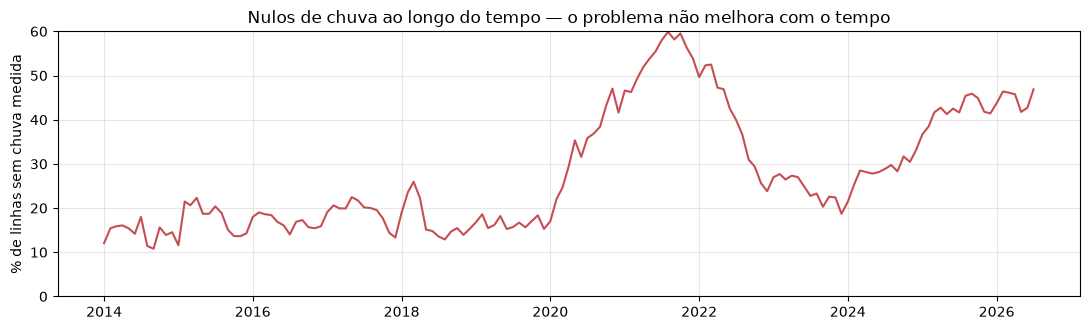

In [14]:
fig, ax = plt.subplots(figsize=(11, 3.4))
serie = df.groupby("data")["chuva_mm_mes"].apply(lambda s: s.isna().mean() * 100)
ax.plot(serie.index, serie.values, color="#C44E52")
ax.set_ylabel("% de linhas sem chuva medida")
ax.set_ylim(0, 60)
ax.set_title("Nulos de chuva ao longo do tempo — o problema não melhora com o tempo")
fig.tight_layout()
plt.show()

Vale notar que a taxa de nulos **não cai** ao longo dos anos, apesar de a rede crescer. Estações
novas trazem consigo os mesmos problemas de sensor das antigas; não é um defeito histórico que
se resolve olhando só para os anos recentes.

In [15]:
por_uf = df.groupby("sigla_uf").agg(
    estacoes=("codigo_estacao", "nunique"),
    linhas=("codigo_estacao", "size"),
    chuva_nula_pct=("chuva_mm_mes", lambda s: s.isna().mean() * 100),
    cobertura_media=("pct_dias_validos", "mean"),
).sort_values("estacoes", ascending=False)
por_uf.round(1)

,estacoes,linhas,chuva_nula_pct,cobertura_media
sigla_uf,,,,
RS,100,6894,16.10,87.40
MG,70,9767,12.80,91.90
MT,65,5659,44.30,68.00
BA,49,6792,32.10,75.80
MS,46,4973,33.50,76.40
SP,43,5746,22.40,85.20
PA,36,4571,40.30,68.20
RJ,27,3521,9.10,93.30
PR,27,3811,29.40,77.30


Aqui está o problema de agregação, em números: **RS tem 100 estações, RR tem 3**. Uma média
simples por UF trataria as três estações de Roraima como estimativa tão confiável quanto as cem
do Rio Grande do Sul. Pior: como a área importa, o T-022 pede ponderação — por área agrícola,
não por contagem de estações.

---
## 5. Sanidade: sazonalidade e geografia

A melhor prova de que o dado está certo não é estatística — é reconhecer nele padrões que já
sabemos existir.

In [16]:
sazonal = df.groupby("mes").agg(
    chuva_mm=("chuva_mm_mes", "mean"),
    temp_media=("temp_media", "mean"),
    umidade=("umidade_media", "mean"),
    dias_secos_seguidos=("max_dias_secos_seguidos", "mean"),
)
sazonal.round(1)

,chuva_mm,temp_media,umidade,dias_secos_seguidos
mes,,,,
1,181.70,24.90,75.40,8.60
2,174.10,24.80,76.60,7.30
3,169.00,24.60,77.20,8.50
4,123.10,23.60,77.00,10.10
5,90.60,21.90,75.80,13.60
6,59.90,20.90,73.40,16.80
7,44.80,20.70,68.20,19.50
8,41.70,21.80,63.90,18.30
9,58.50,23.80,62.60,16.50


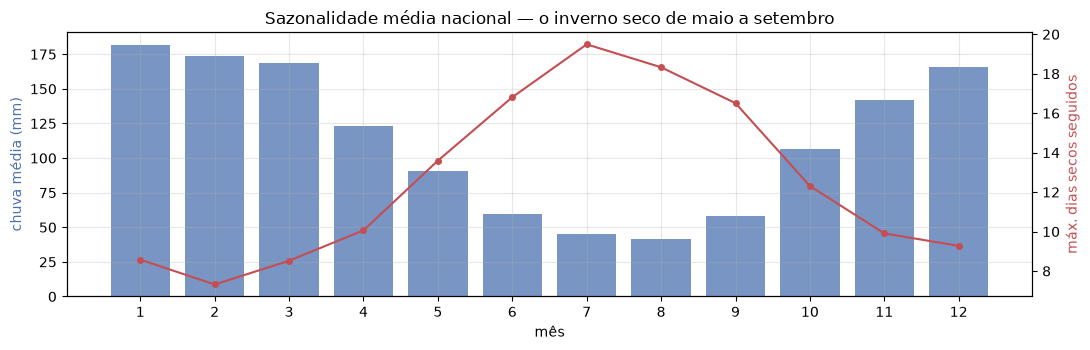

In [17]:
fig, ax1 = plt.subplots(figsize=(11, 3.6))
ax1.bar(sazonal.index, sazonal["chuva_mm"], color="#4C72B0", alpha=0.75, label="chuva")
ax1.set_ylabel("chuva média (mm)", color="#4C72B0")
ax1.set_xticks(range(1, 13))
ax1.set_xlabel("mês")

ax2 = ax1.twinx()
ax2.plot(sazonal.index, sazonal["dias_secos_seguidos"], color="#C44E52", marker="o", ms=4)
ax2.set_ylabel("máx. dias secos seguidos", color="#C44E52")
ax2.grid(False)

ax1.set_title("Sazonalidade média nacional — o inverno seco de maio a setembro")
fig.tight_layout()
plt.show()

O padrão é o esperado e é forte: **janeiro chove 182 mm em média, agosto chove 42 mm** — mais de
4× de diferença. A sequência seca faz o espelho exato, com pico em agosto. Isso é a estação seca
do Brasil central aparecendo sem que ninguém tenha dito ao script o que é inverno.

Consequência prática para a modelagem: **qualquer feature de clima crua carrega essa
sazonalidade**. Comparar a chuva de agosto de um ano com a de janeiro do mesmo ano mede a
estação do ano, não o choque climático. Anomalia contra a média histórica do mesmo mês é o que
isola o sinal.

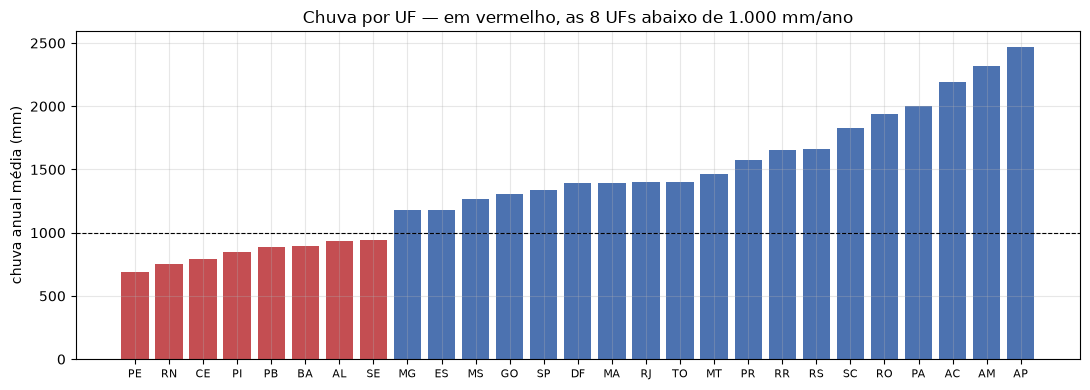

In [18]:
chuva_uf = (df.groupby("sigla_uf")["chuva_mm_mes"].mean() * 12).sort_values()

fig, ax = plt.subplots(figsize=(11, 4))
cores = ["#C44E52" if v < 1000 else "#4C72B0" for v in chuva_uf.values]
ax.bar(range(len(chuva_uf)), chuva_uf.values, color=cores)
ax.set_xticks(range(len(chuva_uf)), chuva_uf.index, fontsize=8)
ax.axhline(1000, color="black", lw=0.8, ls="--")
ax.set_ylabel("chuva anual média (mm)")
ax.set_title("Chuva por UF — em vermelho, as 8 UFs abaixo de 1.000 mm/ano")
fig.tight_layout()
plt.show()

As oito UFs mais secas são **PE, RN, CE, PI, PB, BA, AL e SE** — o semiárido nordestino, na
ordem certa. No outro extremo, AP, AM e AC passam de 2.000 mm. O dado reproduz a geografia
climática brasileira sem ajuda.

Isso é relevante para o projeto: são exatamente essas UFs que aparecem no dataset de seca
(notebook 05) e nas maiores perdas de área plantada (notebook 03).

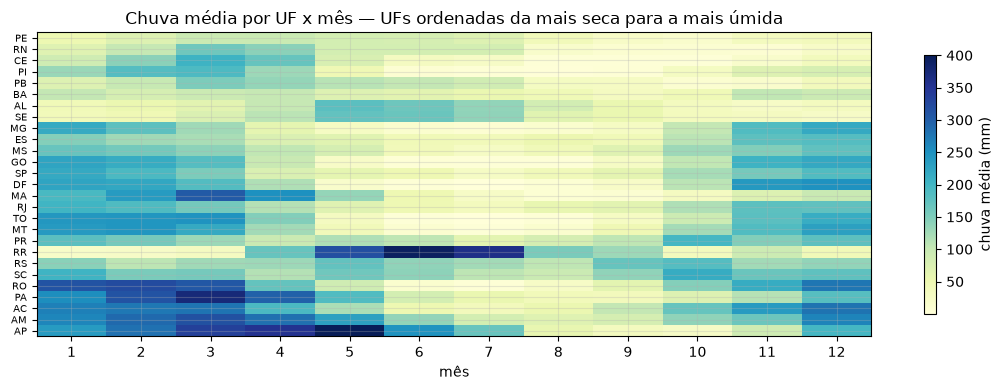

In [19]:
fig, ax = plt.subplots(figsize=(11, 4))
mapa = df.pivot_table(index="sigla_uf", columns="mes", values="chuva_mm_mes", aggfunc="mean")
mapa = mapa.loc[chuva_uf.index]
im = ax.imshow(mapa, cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(12), range(1, 13))
ax.set_yticks(range(len(mapa)), mapa.index, fontsize=7)
ax.set_xlabel("mês")
fig.colorbar(im, shrink=0.85, label="chuva média (mm)")
ax.set_title("Chuva média por UF x mês — UFs ordenadas da mais seca para a mais úmida")
fig.tight_layout()
plt.show()

O regime não é só de volume, é de **calendário**. O Nordeste (faixa de cima) chove no outono —
março e abril. O Centro-Sul chove no verão — dezembro a fevereiro. O Sul (RS, SC) é o único
razoavelmente distribuído no ano. Uma média nacional de chuva por mês, portanto, mistura três
regimes distintos: mais um argumento contra agregar sem ponderar.

---
## 6. Redundância: quais colunas dizem a mesma coisa

Com 28 colunas, boa parte da informação está repetida. A correlação mostra onde.

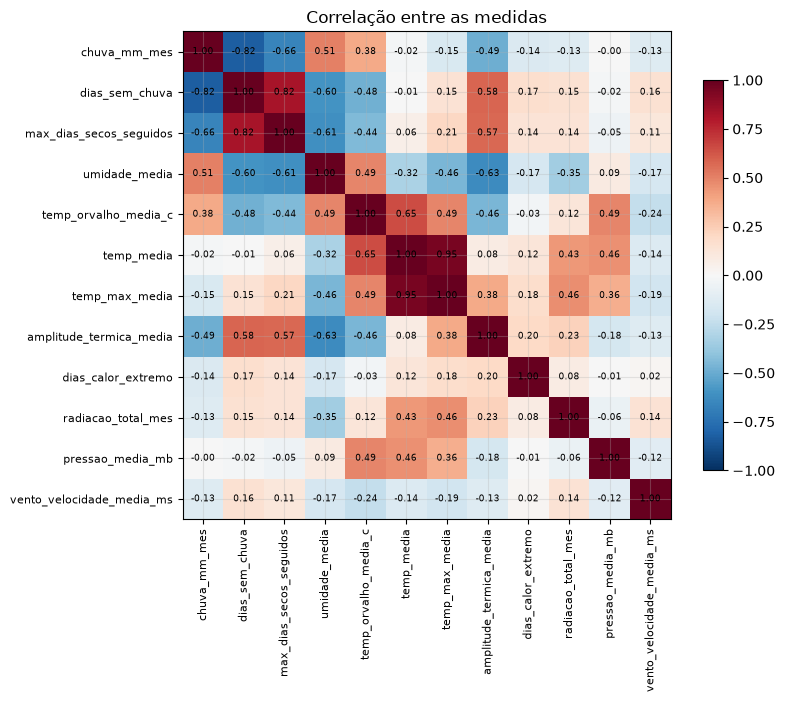

In [20]:
CORE = [
    "chuva_mm_mes",
    "dias_sem_chuva",
    "max_dias_secos_seguidos",
    "umidade_media",
    "temp_orvalho_media_c",
    "temp_media",
    "temp_max_media",
    "amplitude_termica_media",
    "dias_calor_extremo",
    "radiacao_total_mes",
    "pressao_media_mb",
    "vento_velocidade_media_ms",
]
corr = df[CORE].corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(CORE)), CORE, rotation=90, fontsize=8)
ax.set_yticks(range(len(CORE)), CORE, fontsize=8)
for i in range(len(CORE)):
    for j in range(len(CORE)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6.5)
fig.colorbar(im, shrink=0.8)
ax.set_title("Correlação entre as medidas")
fig.tight_layout()
plt.show()

In [21]:
pares = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
pares.sort_values(ascending=False).head(8).to_frame("|correlação|")

,,|correlação|
temp_media,temp_max_media,0.95
chuva_mm_mes,dias_sem_chuva,0.82
dias_sem_chuva,max_dias_secos_seguidos,0.82
chuva_mm_mes,max_dias_secos_seguidos,0.66
temp_orvalho_media_c,temp_media,0.65
umidade_media,amplitude_termica_media,0.63
max_dias_secos_seguidos,umidade_media,0.61
dias_sem_chuva,umidade_media,0.60


Os pares fortes contam uma história coerente:

* **`dias_sem_chuva` ↔ `chuva_mm_mes` (−0,82)** e **`dias_sem_chuva` ↔ `max_dias_secos_seguidos`
  (+0,82)**. As três medem a mesma seca por ângulos diferentes. Manter as três num modelo linear
  é colinearidade quase pura — mas `max_dias_secos_seguidos` carrega algo que as outras não têm:
  a **concentração** da chuva. Dois meses com 80 mm são muito diferentes se um teve 20 dias
  secos seguidos e o outro não.
* **`temp_orvalho_media_c` ↔ `temp_media` (0,65)**. Ponto de orvalho é umidade absoluta, e
  umidade absoluta acompanha temperatura por física.
* **`radiacao_total_mes` ↔ `temp_media` (0,43)**. Sol aquece — o dado concorda.
* **`temp_media` ↔ `chuva_mm_mes` (−0,02)**. Praticamente **zero**, e isso não é um defeito: é o
  Brasil misturando o Nordeste (quente e seco) com a Amazônia (quente e úmida) no mesmo balde.
  Dentro de uma UF a relação existe; entre UFs, ela se cancela. Correlação nacional em painel
  geográfico esconde mais do que revela.

In [22]:
recorte = df[df["sigla_uf"].isin(["CE", "AM", "RS"])]
recorte.groupby("sigla_uf").apply(
    lambda g: g["chuva_mm_mes"].corr(g["temp_media"]), include_groups=False
).to_frame("corr(chuva, temp) dentro da UF")

,"corr(chuva, temp) dentro da UF"
sigla_uf,
AM,-0.46
CE,-0.35
RS,-0.05


Confirmado: **dentro** de cada UF a relação aparece, e é negativa — mês chuvoso é mês de céu
encoberto, portanto mais fresco. No CE (−0,35) e no AM (−0,46) o efeito é claro; no RS (−0,05)
some, porque ali a chuva não se concentra no verão. O zero nacional era um **artefato de
agregação**: estados quentes-e-secos e quentes-e-úmidos se cancelam quando empilhados.

A lição vale para todo o projeto: correlacionar dentro do grupo, nunca no painel empilhado.

---
## O que fica para as próximas etapas

| Ponto | Consequência |
|---|---|
| A linha é **estação × mês**, não UF × mês | Precisa de agregação antes de juntar com preço (T-021) |
| RS tem 100 estações, RR tem 3 | Média simples por UF é enviesada; ponderar por área agrícola (T-022) |
| Grid 79% preenchido — a rede cresce de 475 para 638 estações | Painel desbalanceado; a amostra de 2014 não é a de 2024 |
| **2026 tem só 7 meses** (jan–jul) | Não comparar média anual de 2026 com anos completos |
| `ano_mes` é **texto** `YYYY-MM` | Converter para `datetime` antes de qualquer aritmética de data |
| 28% de nulo em chuva, 23% em temperatura, em blocos por sensor | Nulo não é aleatório: quando o sensor cai, todas as colunas dele caem juntas |
| `pct_dias_validos` explica a nulidade de **temperatura** (0,0% acima de 75% de cobertura) | Corte em 80% preserva 76% das linhas e resolve o lado da temperatura (T-021) |
| **Mas não a de chuva**: 7,6% de nulo mesmo com 100% de cobertura | O pluviômetro falha sozinho; filtrar por cobertura não basta para a variável mais importante |
| Linhas com 50–75% de cobertura têm valor **subestimado** para chuva | Acumulado de meio mês não é comparável; afeta somas, não médias |
| Chuva é assimétrica: mediana 82 mm, máx. 1.381 mm; 5% dos meses com zero | Zero é medição real. Padronizar cru deixa a cauda dominar |
| `dias_chuva_forte` tem mediana zero | É variável de evento, não contínua; média descreve mal |
| Sazonalidade forte: 182 mm em janeiro contra 42 mm em agosto | Usar anomalia contra a média do mesmo mês, não o valor cru |
| Três regimes de chuva distintos (NE no outono, Centro-Sul no verão) | Média nacional mistura calendários incompatíveis |
| `dias_sem_chuva`, `chuva_mm_mes` e `max_dias_secos_seguidos` com \|r\| > 0,8 | Colinear; escolher uma ou usar redução de dimensão |
| `corr(chuva, temp)` nacional ≈ 0, mas ≠ 0 dentro da UF | Correlacionar dentro do grupo, nunca no painel empilhado |
| `pressao_media_mb` é pressão na estação | Proxy de altitude, não de tempo meteorológico |